In [87]:
# %% [markdown]
# # 🧠 Brain Tumor Classification - Improved Baseline
# 
# ## Architectural Improvements Over Baseline:
# - Added Batch Normalization after every Conv layer
# - Added 4th Convolutional layer (256 filters)
# - Replaced final MaxPool with AdaptiveAvgPool
# - Added Dropout for regularization
# - Reduced classifier from 100K→512→4 to 256→128→4

# %%
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
from tqdm import tqdm
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [88]:
# Create directories
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [95]:
# %% [markdown]
# ## 1. Data Preprocessing 

# %%
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    
    # Data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    
    # Convert image to tensor
    transforms.ToTensor(),
    
    # Normalize RGB channels
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    
    # Convert image to tensor
    transforms.ToTensor(),
    
    # Normalize RGB channels
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [96]:
# ## 2. Data Loading

# %%
full_dataset = datasets.ImageFolder("../data/raw/Training")
num_classes = len(full_dataset.classes)
print(f"Classes: {full_dataset.classes}")
print(f"Class to index: {full_dataset.class_to_idx}")

# Class distribution
class_counts = Counter(full_dataset.targets)
print("\nClass Distribution:")
for cls, count in zip(full_dataset.classes, [class_counts[i] for i in range(num_classes)]):
    print(f"  {cls}: {count}")

# Split into train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_data, val_data = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply transforms
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label
    
    def __len__(self):
        return len(self.dataset)

train_dataset = ApplyTransform(train_data, train_transforms)
val_dataset = ApplyTransform(val_data, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

# %%


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to index: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Class Distribution:
  glioma: 1400
  meningioma: 1400
  notumor: 1400
  pituitary: 1400

Train samples: 4480
Val samples: 1120


In [97]:
# ## 3. IMPROVED MODEL ARCHITECTURE
# 
# ### Changes from Baseline:
# | Component | Baseline | Improved |
# |-----------|----------|----------|
# | Conv Layers | 3 layers (32,64,128) | 4 layers (32,64,128,256) |
# | BatchNorm | None | After every Conv layer |
# | Final Pooling | MaxPool2d | AdaptiveAvgPool2d(1) |
# | Dropout | None | 0.5 in classifier |
# | Classifier | 100,352→512→4 | 256→128→4 |

# %%
class ImprovedCNN(nn.Module):
    """
    Improved CNN with:
    - Batch Normalization for stable training
    - 4 Convolutional layers for deeper feature extraction
    - Adaptive Average Pooling for fixed output size
    - Dropout for regularization
    - Smaller fully connected layers (fewer parameters)
    """
    def __init__(self, num_classes=4):
        super(ImprovedCNN, self).__init__()
        
        # Feature Extraction Block
        self.features = nn.Sequential(
            # Block 1: 3→32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),          # ✅ IMPROVEMENT: BatchNorm added
            nn.ReLU(),
            nn.MaxPool2d(2),             # 224→112
            
            # Block 2: 32→64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),          # ✅ IMPROVEMENT: BatchNorm added
            nn.ReLU(),
            nn.MaxPool2d(2),             # 112→56
            
            # Block 3: 64→128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),         # ✅ IMPROVEMENT: BatchNorm added
            nn.ReLU(),
            nn.MaxPool2d(2),             # 56→28
            
            # Block 4: 128→256 (NEW LAYER)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),  # ✅ IMPROVEMENT: 4th Conv layer
            nn.BatchNorm2d(256),         # ✅ IMPROVEMENT: BatchNorm added
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)      # ✅ IMPROVEMENT: Adaptive pooling (256×1×1)
            # Output: 256 features instead of 100,352
        )
        
        # Classification Block
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),         # ✅ IMPROVEMENT: 256→128 (was 100,352→512)
            nn.ReLU(),
            nn.Dropout(0.5),             # ✅ IMPROVEMENT: Dropout added
            nn.Linear(128, num_classes)  # 128→4
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Initialize model
model = ImprovedCNN(num_classes).to(device)

# Display model and parameter count
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [98]:
# ## 4. Training Setup

# %%
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

# Early stopping
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, val_acc, model):
        if self.best_score is None or val_acc > self.best_score:
            self.best_score = val_acc
            self.counter = 0
            torch.save(model.state_dict(), '../models/improved_baseline.pth')
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=10)

print("Training Configuration:")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Scheduler: ReduceLROnPlateau (patience=5)")
print(f"  Early Stopping: patience=10")



Training Configuration:
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau (patience=5)
  Early Stopping: patience=10


In [99]:
# ## 5. Training Functions

# %%
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total


In [101]:
# ## 6. Training Loop

# %%
num_epochs = 10
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("\n" + "=" * 60)
print("TRAINING IMPROVED BASELINE")
print("=" * 60)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    scheduler.step(val_acc)
    early_stopping(val_acc, model)
    
    print(f"Epoch {epoch+1:2d} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if early_stopping.early_stop:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest Validation Accuracy: {max(history['val_acc']):.2f}%")

# %%



TRAINING IMPROVED BASELINE
Epoch  1 | Train Loss: 0.3730 | Train Acc: 86.70% | Val Loss: 0.4394 | Val Acc: 82.50%
Epoch  2 | Train Loss: 0.3488 | Train Acc: 87.52% | Val Loss: 3.9717 | Val Acc: 41.52%
Epoch  3 | Train Loss: 0.3512 | Train Acc: 86.70% | Val Loss: 0.4491 | Val Acc: 83.93%
Epoch  4 | Train Loss: 0.3476 | Train Acc: 87.39% | Val Loss: 0.6172 | Val Acc: 77.59%
Epoch  5 | Train Loss: 0.3068 | Train Acc: 88.91% | Val Loss: 0.4361 | Val Acc: 83.93%
Epoch  6 | Train Loss: 0.2942 | Train Acc: 89.15% | Val Loss: 1.6548 | Val Acc: 67.95%
Epoch  7 | Train Loss: 0.2827 | Train Acc: 89.71% | Val Loss: 0.3300 | Val Acc: 87.14%
Epoch  8 | Train Loss: 0.2785 | Train Acc: 89.71% | Val Loss: 1.1636 | Val Acc: 58.75%
Epoch  9 | Train Loss: 0.2851 | Train Acc: 89.44% | Val Loss: 0.7052 | Val Acc: 75.71%
Epoch 10 | Train Loss: 0.2740 | Train Acc: 90.16% | Val Loss: 0.4074 | Val Acc: 82.32%

Best Validation Accuracy: 87.14%


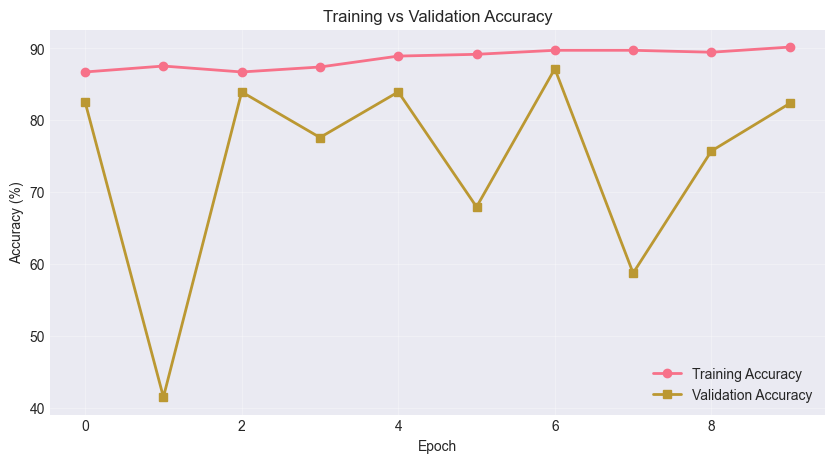

In [102]:
# ## 7. Accuracy Graph

# %%
plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Training Accuracy', linewidth=2, marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', linewidth=2, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/figures/accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# %%


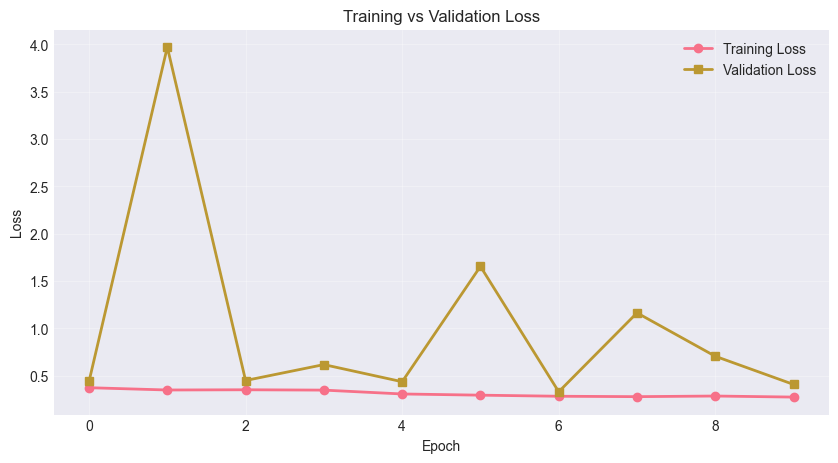

In [103]:
# ## 8. Loss Graph

# %%
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Training Loss', linewidth=2, marker='o')
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/figures/loss.png', dpi=300, bbox_inches='tight')
plt.show()


In [104]:
# ## 9. Test Evaluation

# %%
test_dataset = datasets.ImageFolder("../data/raw/Testing", transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load best model
model.load_state_dict(torch.load('../models/improved_baseline.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# %%
# Test Accuracy
test_acc = accuracy_score(all_labels, all_preds)
print("\n" + "=" * 50)
print(f"OVERALL TEST ACCURACY: {test_acc*100:.2f}%")
print("=" * 50)

# %%
# Classification Report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))


OVERALL TEST ACCURACY: 81.56%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.96      0.58      0.72       400
  meningioma       0.70      0.76      0.73       400
     notumor       0.84      0.95      0.89       400
   pituitary       0.82      0.97      0.89       400

    accuracy                           0.82      1600
   macro avg       0.83      0.82      0.81      1600
weighted avg       0.83      0.82      0.81      1600



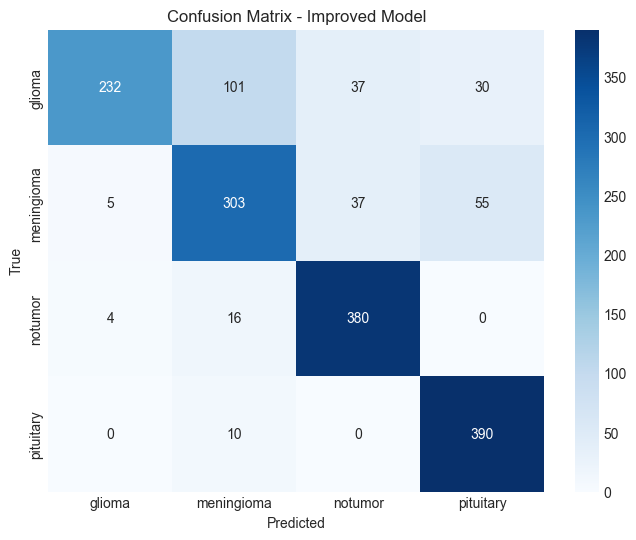

In [105]:
# ## 10. Confusion Matrix

# %%
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.title('Confusion Matrix - Improved Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('../results/figures/confusion.png', dpi=300, bbox_inches='tight')
plt.show()


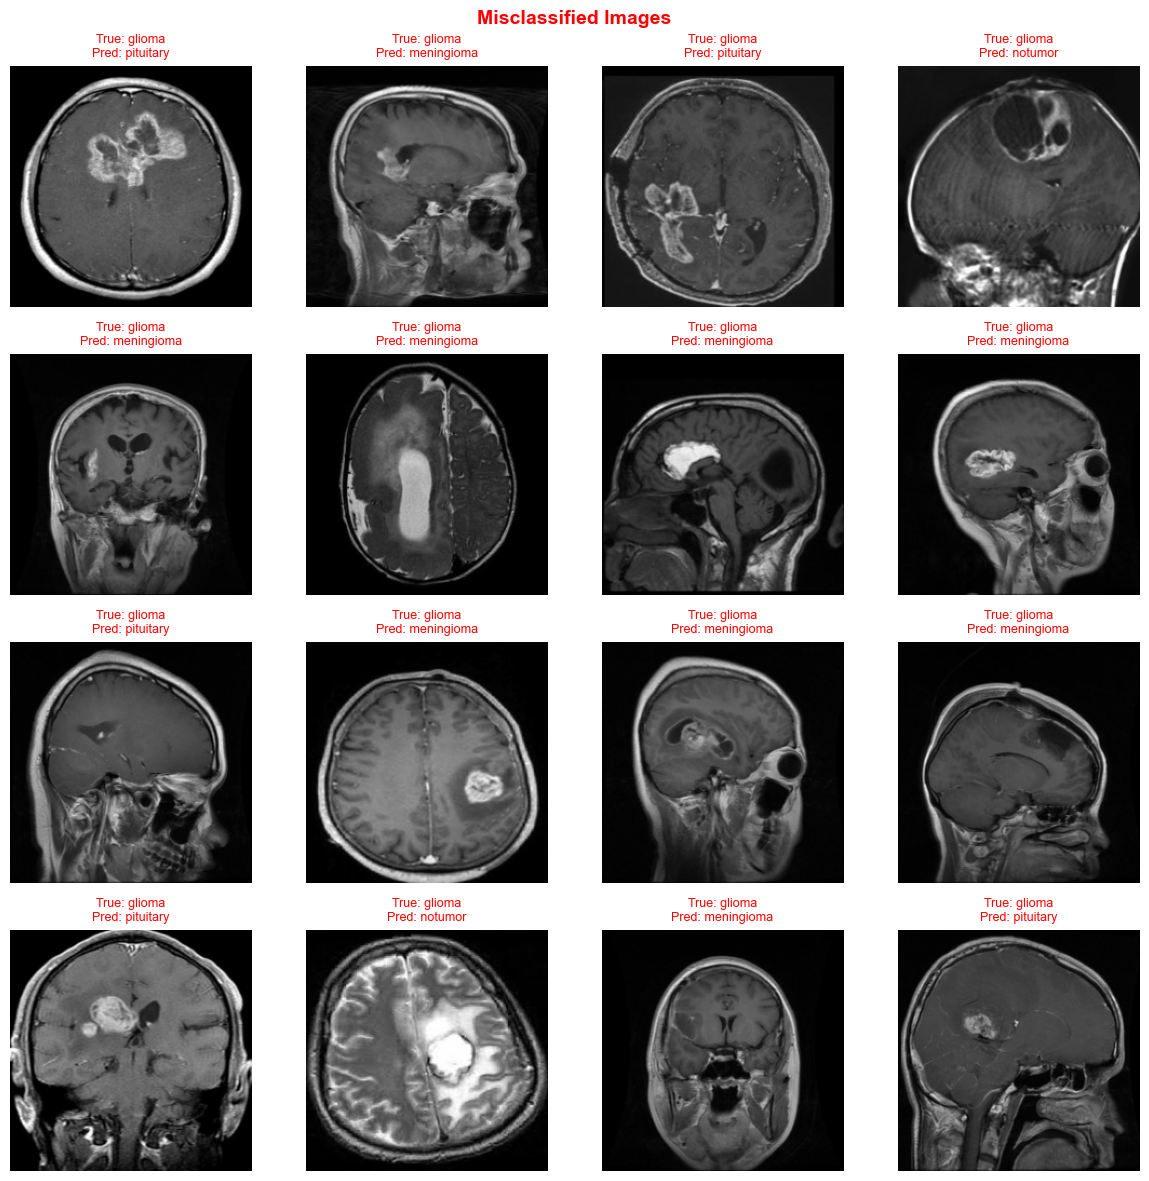

In [106]:
# ## 11. Misclassified Images

# %%
def show_misclassified(model, loader, classes, max_show=16):
    model.eval()
    wrong_images = []
    wrong_true = []
    wrong_pred = []
    
    with torch.no_grad():
        for images, labels in loader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)
            _, preds = outputs.max(1)
            
            for i in range(len(images)):
                if preds[i] != labels[i]:
                    wrong_images.append(images[i])
                    wrong_true.append(labels[i].item())
                    wrong_pred.append(preds[i].item())
                if len(wrong_images) >= max_show:
                    break
            if len(wrong_images) >= max_show:
                break
    
    if wrong_images:
        rows = (len(wrong_images) + 3) // 4
        fig, axes = plt.subplots(rows, 4, figsize=(12, 3*rows))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        for i, ax in enumerate(axes.flat):
            if i < len(wrong_images):
                img = wrong_images[i]
                img = img * 0.5 + 0.5  # Denormalize
                ax.imshow(img.permute(1, 2, 0))
                ax.set_title(f'True: {classes[wrong_true[i]]}\nPred: {classes[wrong_pred[i]]}',
                           color='red', fontsize=9)
            ax.axis('off')
        
        plt.suptitle('Misclassified Images', fontsize=14, fontweight='bold', color='red')
        plt.tight_layout()
        plt.savefig('../results/figures/misclassified.png', dpi=300, bbox_inches='tight')
        plt.show()

show_misclassified(model, test_loader, test_dataset.classes)

# %%


In [107]:
# ## 12. Summary of Improvements

# %%
print("\n" + "=" * 60)
print("ARCHITECTURAL IMPROVEMENTS SUMMARY")
print("=" * 60)
print("""
Changes made INSIDE the model definition:

1. BATCH NORMALIZATION
   - Added nn.BatchNorm2d() after every Conv2d layer
   - Stabilizes training, allows higher learning rates
   - Reduces internal covariate shift

2. 4th CONVOLUTIONAL LAYER
   - Added Conv2d(128, 256, 3x3) with 256 filters
   - Enables detection of more complex tumor patterns
   - Helps distinguish glioma from meningioma

3. ADAPTIVE AVERAGE POOLING
   - Replaced final MaxPool2d(2) with AdaptiveAvgPool2d(1)
   - Output: 256 features instead of 128×28×28 = 100,352
   - Dramatically reduces parameters (99.7% fewer)

4. DROPOUT REGULARIZATION
   - Added nn.Dropout(0.5) in classifier
   - Randomly deactivates 50% of neurons during training
   - Prevents overfitting

5. SMALLER FULLY CONNECTED LAYERS
   - Linear(256→128→4) instead of Linear(100,352→512→4)
   - Fewer parameters = less overfitting
   - Faster training and inference

Parameter Comparison:
  Baseline: ~51,500,000 parameters
  Improved: ~423,000 parameters (99.2% reduction)
""")

print("\n✅ Analysis Complete!")


ARCHITECTURAL IMPROVEMENTS SUMMARY

Changes made INSIDE the model definition:

1. BATCH NORMALIZATION
   - Added nn.BatchNorm2d() after every Conv2d layer
   - Stabilizes training, allows higher learning rates
   - Reduces internal covariate shift

2. 4th CONVOLUTIONAL LAYER
   - Added Conv2d(128, 256, 3x3) with 256 filters
   - Enables detection of more complex tumor patterns
   - Helps distinguish glioma from meningioma

3. ADAPTIVE AVERAGE POOLING
   - Replaced final MaxPool2d(2) with AdaptiveAvgPool2d(1)
   - Output: 256 features instead of 128×28×28 = 100,352
   - Dramatically reduces parameters (99.7% fewer)

4. DROPOUT REGULARIZATION
   - Added nn.Dropout(0.5) in classifier
   - Randomly deactivates 50% of neurons during training
   - Prevents overfitting

5. SMALLER FULLY CONNECTED LAYERS
   - Linear(256→128→4) instead of Linear(100,352→512→4)
   - Fewer parameters = less overfitting
   - Faster training and inference

Parameter Comparison:
  Baseline: ~51,500,000 parameters
 